# Практика 18. Множинна лінійна регресія

**Студент:** Коць Артем  
**Група:** ІТ-42  
**Варіант:** 9  
**Місто:** Суми

## Мета роботи

Побудувати моделі множинної лінійної регресії за допомогою `statsmodels.OLS`,
проаналізувати коефіцієнти регресії, R² та adjusted R², перевірити
мультиколінеарність через VIF і провести діагностику залишків.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import probplot, shapiro, linregress
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [6]:
np.random.seed(42)

city = "Суми"
mean_temp = 7.5
amplitude = 14
hum_base = 73

rows = []

for month in range(1, 13):
    temp = (
        mean_temp
        + amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
        + np.random.normal(0, 1.0)
    )

    humidity = hum_base + np.random.normal(0, 5.0)

    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1),
    })

heating = pd.DataFrame(rows)

print("Студент: Коць Артем")
print("Група: ІТ-42")
print("Варіант: 9")
print("Місто:", city)

display(heating)

Студент: Коць Артем
Група: ІТ-42
Варіант: 9
Місто: Суми


,місто,місяць,температура,вологість,опалювальні_дні,витрати_на_опалення
0,Суми,1,-6.0,72.3,30,382.1
1,Суми,2,-3.1,71.8,30,342.5
2,Суми,3,2.1,76.8,30,295.3
3,Суми,4,8.0,70.7,15,200.5
4,Суми,5,14.7,63.4,0,79.5
5,Суми,6,19.1,67.9,0,73.9
6,Суми,7,20.6,65.9,0,76.2
7,Суми,8,19.4,73.3,0,48.0
8,Суми,9,14.0,73.6,0,101.3
9,Суми,10,7.9,70.0,30,241.7


In [3]:
print("Розмір DataFrame:", heating.shape)

print("\nТипи даних:")
print(heating.dtypes)

print("\nПропуски:")
print(heating.isna().sum())

print("\nОпис числових стовпців:")
display(heating.describe())

Розмір DataFrame: (12, 6)

Типи даних:
місто                      str
місяць                   int64
температура            float64
вологість              float64
опалювальні_дні          int64
витрати_на_опалення    float64
dtype: object

Пропуски:
місто                  0
місяць                 0
температура            0
вологість              0
опалювальні_дні        0
витрати_на_опалення    0
dtype: int64

Опис числових стовпців:


,місяць,температура,вологість,опалювальні_дні,витрати_на_опалення
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.500000,7.575000,72.091667,16.250000,210.016667
std,3.605551,9.990825,5.161828,14.943074,128.301597
min,1.000000,-6.000000,63.400000,0.000000,48.000000
25%,3.750000,-0.850000,69.475000,0.000000,78.675000
50%,6.500000,7.950000,72.050000,22.500000,221.100000
75%,9.250000,15.800000,74.400000,30.000000,329.450000
max,12.000000,20.600000,82.300000,30.000000,382.100000


In [4]:
print("Розмір DataFrame:", heating.shape)

print("\nТипи даних:")
print(heating.dtypes)

print("\nПропуски:")
print(heating.isna().sum())

print("\nОпис числових стовпців:")
display(heating.describe())

Розмір DataFrame: (12, 6)

Типи даних:
місто                      str
місяць                   int64
температура            float64
вологість              float64
опалювальні_дні          int64
витрати_на_опалення    float64
dtype: object

Пропуски:
місто                  0
місяць                 0
температура            0
вологість              0
опалювальні_дні        0
витрати_на_опалення    0
dtype: int64

Опис числових стовпців:


,місяць,температура,вологість,опалювальні_дні,витрати_на_опалення
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.500000,7.575000,72.091667,16.250000,210.016667
std,3.605551,9.990825,5.161828,14.943074,128.301597
min,1.000000,-6.000000,63.400000,0.000000,48.000000
25%,3.750000,-0.850000,69.475000,0.000000,78.675000
50%,6.500000,7.950000,72.050000,22.500000,221.100000
75%,9.250000,15.800000,74.400000,30.000000,329.450000
max,12.000000,20.600000,82.300000,30.000000,382.100000


In [9]:
print("=== МОДЕЛЬ З ДВОМА ПРЕДИКТОРАМИ ===")

print(f"R² = {model_2.rsquared:.6f}")
print(f"Adjusted R² = {model_2.rsquared_adj:.6f}")

print("\nКоефіцієнти:")
print(model_2.params)

print("\np-value:")
print(model_2.pvalues)

=== МОДЕЛЬ З ДВОМА ПРЕДИКТОРАМИ ===
R² = 0.967214
Adjusted R² = 0.959929

Коефіцієнти:
const          249.642364
температура    -12.393789
вологість        0.752615
dtype: float64

p-value:
const          1.070673e-01
температура    4.343285e-07
вологість      6.966570e-01
dtype: float64


In [8]:
X = heating[["температура", "вологість"]]
X = sm.add_constant(X)

y = heating["витрати_на_опалення"]

model_2 = sm.OLS(y, X).fit()

print(model_2.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.967
Model:                             OLS   Adj. R-squared:                  0.960
Method:                  Least Squares   F-statistic:                     132.8
Date:                 Mon, 07 Sep 2026   Prob (F-statistic):           2.09e-07
Time:                         12:27:48   Log-Likelihood:                -54.251
No. Observations:                   12   AIC:                             114.5
Df Residuals:                        9   BIC:                             116.0
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         249.6424    139.463      1

In [10]:
vif_data = pd.DataFrame()

vif_data["Предиктор"] = ["температура", "вологість"]

vif_data["VIF"] = [
    variance_inflation_factor(X.values, 1),
    variance_inflation_factor(X.values, 2)
]

display(vif_data.round(3))

,Предиктор,VIF
0,температура,1.553
1,вологість,1.553


In [11]:
print("=== ОЦІНКА МУЛЬТИКОЛІНЕАРНОСТІ ===")

for _, row in vif_data.iterrows():
    predictor = row["Предиктор"]
    vif = row["VIF"]

    print(f"{predictor}: VIF = {vif:.3f}")

    if vif > 10:
        print("  Висока мультиколінеарність: проблема.")
    elif vif > 5:
        print("  Підвищений VIF: потрібна увага.")
    else:
        print("  Критичної мультиколінеарності немає.")

=== ОЦІНКА МУЛЬТИКОЛІНЕАРНОСТІ ===
температура: VIF = 1.553
  Критичної мультиколінеарності немає.
вологість: VIF = 1.553
  Критичної мультиколінеарності немає.


## Висновок щодо VIF

VIF приблизно 1 означає практичну відсутність мультиколінеарності.
Значення VIF понад 5 є сигналом для уваги, а понад 10 свідчить
про серйозну мультиколінеарність.

У нашому наборі температура та вологість генеруються незалежно:
вологість не обчислюється через температуру. Тому між цими двома
предикторами не очікується жорсткої лінійної залежності.

In [12]:
X3 = heating[
    ["температура", "вологість", "опалювальні_дні"]
]

X3 = sm.add_constant(X3)

model_3 = sm.OLS(y, X3).fit()

print(model_3.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.990
Model:                             OLS   Adj. R-squared:                  0.986
Method:                  Least Squares   F-statistic:                     257.7
Date:                 Mon, 07 Sep 2026   Prob (F-statistic):           2.69e-08
Time:                         12:28:46   Log-Likelihood:                -47.269
No. Observations:                   12   AIC:                             102.5
Df Residuals:                        8   BIC:                             104.5
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             224.4146     8

In [13]:
comparison = pd.DataFrame({
    "Модель": [
        "2 предиктори",
        "3 предиктори"
    ],
    "R²": [
        model_2.rsquared,
        model_3.rsquared
    ],
    "Adjusted R²": [
        model_2.rsquared_adj,
        model_3.rsquared_adj
    ]
})

display(comparison.round(6))

,Модель,R²,Adjusted R²
0,2 предиктори,0.967214,0.959929
1,3 предиктори,0.989760,0.985920


In [14]:
vif_3 = pd.DataFrame()

vif_3["Предиктор"] = [
    "температура",
    "вологість",
    "опалювальні_дні"
]

vif_3["VIF"] = [
    variance_inflation_factor(X3.values, 1),
    variance_inflation_factor(X3.values, 2),
    variance_inflation_factor(X3.values, 3)
]

display(vif_3.round(3))

,Предиктор,VIF
0,температура,6.328
1,вологість,1.602
2,опалювальні_дні,6.403


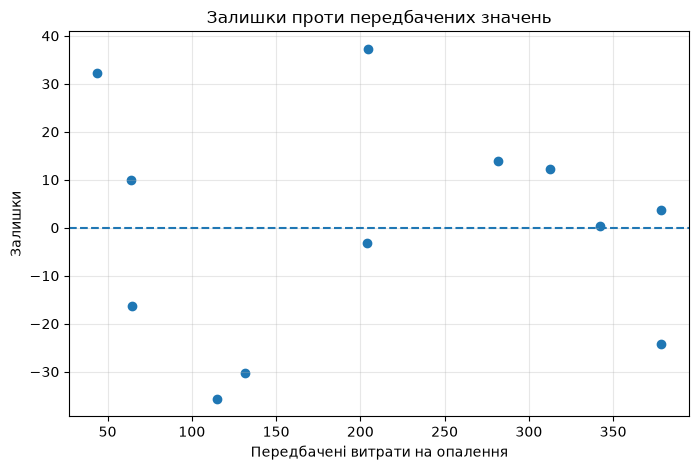

In [15]:
fitted = model_2.fittedvalues
residuals = model_2.resid

plt.figure(figsize=(8, 5))

plt.scatter(fitted, residuals)
plt.axhline(0, linestyle="--")

plt.xlabel("Передбачені витрати на опалення")
plt.ylabel("Залишки")
plt.title("Залишки проти передбачених значень")

plt.grid(True, alpha=0.3)
plt.show()

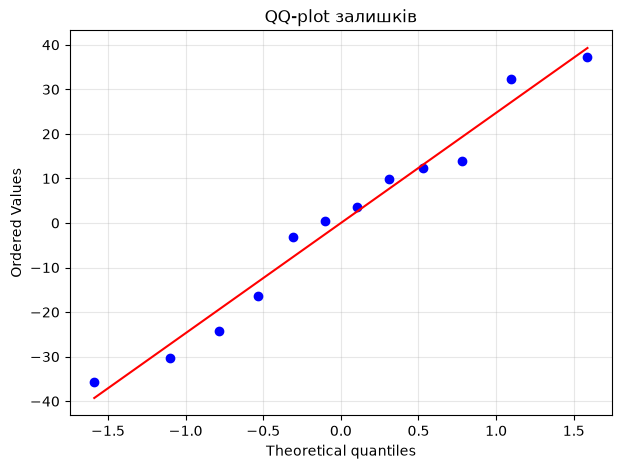

In [16]:
plt.figure(figsize=(7, 5))

probplot(residuals, dist="norm", plot=plt)

plt.title("QQ-plot залишків")
plt.grid(True, alpha=0.3)

plt.show()

In [17]:
shapiro_result = shapiro(residuals)

print(f"Статистика Шапіро-Вілка: {shapiro_result.statistic:.6f}")
print(f"p-value: {shapiro_result.pvalue:.6f}")

alpha = 0.05

if shapiro_result.pvalue < alpha:
    print("\nВідхиляємо H0.")
    print("Є підстави вважати, що залишки не є нормально розподіленими.")
else:
    print("\nНе відхиляємо H0.")
    print("Немає достатніх підстав відкидати нормальність залишків.")

Статистика Шапіро-Вілка: 0.960606
p-value: 0.792444

Не відхиляємо H0.
Немає достатніх підстав відкидати нормальність залишків.


In [18]:
X_simple = sm.add_constant(heating["температура"])

simple_model = sm.OLS(y, X_simple).fit()

print(simple_model.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.967
Model:                             OLS   Adj. R-squared:                  0.963
Method:                  Least Squares   F-statistic:                     289.6
Date:                 Mon, 07 Sep 2026   Prob (F-statistic):           1.03e-08
Time:                         12:29:37   Log-Likelihood:                -54.358
No. Observations:                   12   AIC:                             112.7
Df Residuals:                       10   BIC:                             113.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         305.6572      9.052     33

In [19]:
final_comparison = pd.DataFrame({
    "Модель": [
        "Проста: температура",
        "Множинна: температура + вологість",
        "Множинна: температура + вологість + опалювальні дні"
    ],
    "R²": [
        simple_model.rsquared,
        model_2.rsquared,
        model_3.rsquared
    ],
    "Adjusted R²": [
        simple_model.rsquared_adj,
        model_2.rsquared_adj,
        model_3.rsquared_adj
    ]
})

display(final_comparison.round(6))

,Модель,R²,Adjusted R²
0,Проста: температура,0.966624,0.963286
1,Множинна: температура + вологість,0.967214,0.959929
2,Множинна: температура + вологість + опалювальн...,0.989760,0.985920


In [20]:
r2_change = model_2.rsquared - simple_model.rsquared
adj_change = model_2.rsquared_adj - simple_model.rsquared_adj

print(f"Зміна R² після додавання вологості: {r2_change:.6f}")
print(f"Зміна adjusted R²: {adj_change:.6f}")

if r2_change > 0:
    print("\nR² збільшився після додавання вологості.")
else:
    print("\nR² не збільшився.")

if adj_change > 0:
    print("Adjusted R² також збільшився.")
else:
    print("Adjusted R² не збільшився.")

Зміна R² після додавання вологості: 0.000590
Зміна adjusted R²: -0.003358

R² збільшився після додавання вологості.
Adjusted R² не збільшився.


# Контрольні питання

### 1. Чому `sm.add_constant()` є важливим перед `sm.OLS()`?

`sm.add_constant()` додає до матриці предикторів стовпець одиниць.
Це дозволяє моделі оцінити вільний член (intercept). Без цього
модель не матиме звичайного окремого вільного члена.

### 2. Чим коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії?

У множинній регресії коефіцієнт показує зміну залежної змінної
при зміні конкретного предиктора на одну одиницю за незмінності
інших предикторів.

У простій регресії інших предикторів немає, тому такий ефект
не контролюється.

### 3. Чому R² не може зменшитися після додавання предиктора?

Додавання нового предиктора дає методу найменших квадратів
додаткову можливість пояснити варіацію залежної змінної.
Тому сума квадратів залишків не може збільшитися, а R²
не може зменшитися.

Однак звичайний R² не враховує кількість предикторів.
Тому для порівняння моделей різної складності доцільно
використовувати adjusted R².

### 4. Що означає VIF ≈ 1 та VIF > 10?

VIF приблизно 1 означає, що предиктор практично не пов'язаний
лінійно з іншими предикторами.

VIF понад 10 свідчить про серйозну мультиколінеарність.
У такому випадку необхідно перевірити пов'язані предиктори
та за потреби вилучити один із них або змінити модель.